### 3D rotation of the lightcone

Author: Soumya Shreeram

Date: 24th Jan 2024

Contact: shreeram@mpe.mpg.de

In [ ]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# plotting imports
import matplotlib.pyplot as plt

In [3]:
%load_ext autoreload
%autoreload 2

## Exploring rotation in 3D

In [4]:
def plot_rotated_axes(ax, r, name=None, offset=(0, 0, 0), scale=1, new_ax: bool = False):
    colors = ("#FF6666", "#005533", "#1199EE")  # Colorblind-safe RGB
    loc = np.array([offset, offset])
    for i, (axis, c) in enumerate(zip((ax.xaxis, ax.yaxis, ax.zaxis),
                                      colors)):
        if new_ax:
                axlabel =f"{axis.axis_name}'"
        else:
                axlabel = axis.axis_name
        axis.set_label_text(axlabel)
        axis.label.set_color(c)
        axis.line.set_color(c)
        axis.set_tick_params(colors=c)
        line = np.zeros((2, 3))
        line[1, i] = scale
        line_rot = r.apply(line)
        line_plot = line_rot + loc
        ax.plot(line_plot[:, 0], line_plot[:, 1], line_plot[:, 2], c)
        text_loc = line[1]*1.2
        text_loc_rot = r.apply(text_loc)
        text_plot = text_loc_rot + loc[0]
        ax.text(*text_plot, axlabel.upper(), color=c,
                va="center", ha="center")
    ax.text(*offset, name, color="k", va="center", ha="center",
            bbox={"fc": "w", "alpha": 0.8, "boxstyle": "circle"})

In [16]:
r0 = R.identity()
r1 = R.from_euler("zyx", [5.0821, -2.3184, 0], degrees=True)  # extrinsic

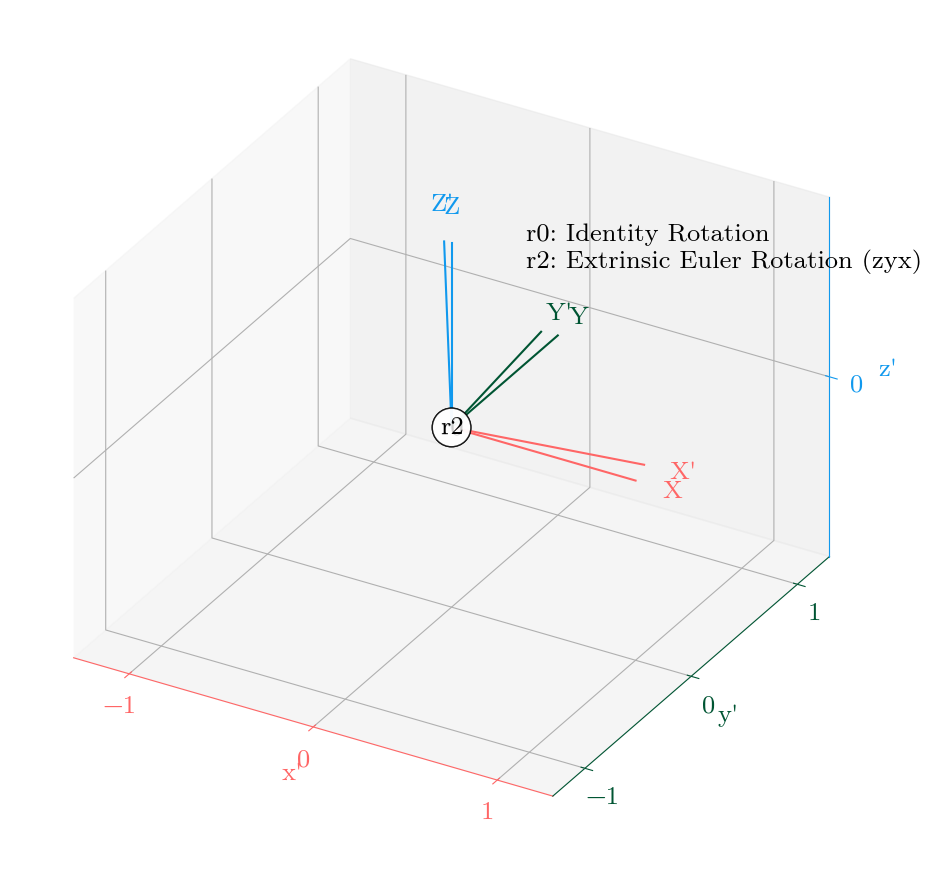

In [17]:
ax = plt.figure().add_subplot(projection="3d", proj_type="ortho")
plot_rotated_axes(ax, r0, name="r0", offset=(0, 0, 0))
plot_rotated_axes(ax, r1, name="r2", offset=(0, 0, 0), new_ax=True)
_ = ax.annotate(
    "r0: Identity Rotation\n"
    "r2: Extrinsic Euler Rotation (zyx)",
    xy=(0.6, 0.7), xycoords="axes fraction", ha="left"
)
ax.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), zlim=(-1.25, 1.25))
ax.set(xticks=[-1, 0, 1], yticks=[-1, 0, 1], zticks=[-1, 0, 1])
ax.set_aspect("equal", adjustable="box")
ax.figure.set_size_inches(10, 15)
plt.tight_layout()

In [18]:
r1.as_matrix()

array([[ 9.95253462e-01, -8.85106062e-02, -4.04526723e-02],
       [ 8.85831154e-02,  9.96068789e-01,  2.16840434e-19],
       [ 4.02936443e-02, -3.58342374e-03,  9.99181456e-01]])

So we apply this rotation to the lightcone to center the observer in the y-z plane. The function is below and also provided in `util.py`.

In [ ]:
def rotation_matrix(coords):
    """Function provides the rotation matrix to center the y-z plane particles along the x-axis 

    Notes
    -----
        - Matrix obtained with scipy.spatial.transform.Rotation
        - see Notebook 12_Rotation.ipynb for more details
        - validation of the matrix done in notebook 02_get_lightcone_geometry.ipynb
    """
    rot_mat = np.array([[ 9.95253462e-01, -8.85106062e-02, -4.04526723e-02],
       [ 8.85831154e-02,  9.96068789e-01,  2.16840434e-19],
       [ 4.02936443e-02, -3.58342374e-03,  9.99181456e-01]])
    coord_rot =  coords @ rot_mat

    coord_rot = coord_rot.astype(np.double)
    return coord_rot